In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("House_price.csv")

In [4]:
data.head()

,area,bedrooms,age,price
0,850,2,5,45
1,900,2,7,43
2,1000,2,6,50
3,1100,3,8,52
4,1200,3,10,58


In [5]:
data.isnull().sum()

area        0
bedrooms    0
age         0
price       0
dtype: int64

In [6]:
data.shape

(20, 4)

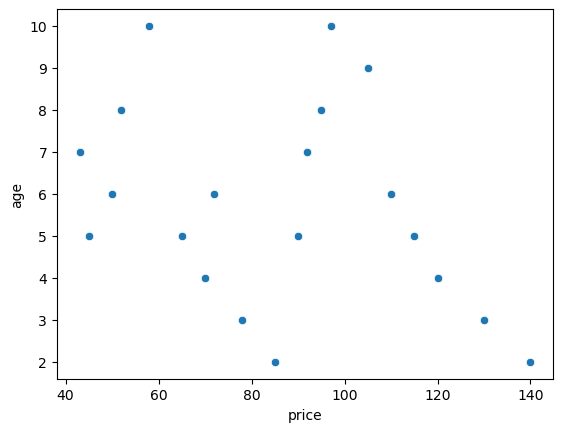

In [11]:
sns.scatterplot(x="price",y="age",data=data)
plt.show()

In [14]:
x=data.iloc[:,:-1]
y=data["price"]

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr=LinearRegression()

In [21]:
lr.fit(x_train,y_train)

LinearRegression()

In [35]:
lr.score(x_train,y_train)*100

99.71608237983084

In [36]:
lr.score(x_test,y_test)*100

99.67386085926508

In [37]:
x_new = pd.DataFrame(
    [[850,2,5]],
    columns=lr.feature_names_in_
)

lr.predict(x_new)

array([42.67405756])

In [39]:
y_pred = lr.predict(x_test)

In [40]:
y_pred

array([ 42.67405756, 122.7654346 , 111.83324296,  43.43800683])

In [41]:
from sklearn.metrics import r2_score,mean_squared_error


In [42]:
r2_score=r2_score(y_test,y_pred)

In [44]:
r2_score*100

99.67386085926508

In [51]:
mean_sq_error=mean_squared_error(y_test,y_pred)

In [52]:
mean_sq_error

4.15256660940741

In [59]:
predictions = lr.predict(x)

result = x.copy()

result["predicted_price"] = predictions

In [60]:
predictions

array([ 42.67405756,  43.43800683,  48.90410265,  52.7103493 ,
        55.81352675,  64.43018039,  69.89627621,  72.99945366,
        80.04082839,  86.20999341,  88.5255314 ,  91.62870885,
        95.51952576,  98.62270321, 104.79186823, 111.83324296,
       117.29933878, 122.7654346 , 128.23153041, 138.37608259])

In [61]:
result

,area,bedrooms,age,predicted_price
0,850,2,5,42.674058
1,900,2,7,43.438007
2,1000,2,6,48.904103
3,1100,3,8,52.710349
4,1200,3,10,55.813527
5,1300,3,5,64.430180
6,1400,3,4,69.896276
7,1500,3,6,72.999454
8,1600,3,3,80.040828
9,1700,4,2,86.209993


In [63]:
result.to_csv("Predicted_price.csv",index=False)

In [64]:
import joblib

In [66]:
joblib.dump(lr, "house_price_model.pkl")

['house_price_model.pkl']

In [67]:
import os
print(os.path.exists('house_price_model.pkl'))

True


In [68]:
loaded_model = joblib.load("house_price_model.pkl")

In [69]:
loaded_model

LinearRegression()

In [70]:
loaded_model.predict(x)

array([ 42.67405756,  43.43800683,  48.90410265,  52.7103493 ,
        55.81352675,  64.43018039,  69.89627621,  72.99945366,
        80.04082839,  86.20999341,  88.5255314 ,  91.62870885,
        95.51952576,  98.62270321, 104.79186823, 111.83324296,
       117.29933878, 122.7654346 , 128.23153041, 138.37608259])

In [73]:
print(lr.predict(x))

[ 42.67405756  43.43800683  48.90410265  52.7103493   55.81352675
  64.43018039  69.89627621  72.99945366  80.04082839  86.20999341
  88.5255314   91.62870885  95.51952576  98.62270321 104.79186823
 111.83324296 117.29933878 122.7654346  128.23153041 138.37608259]


In [74]:
print(loaded_model.predict(x))            850	2	5	

[ 42.67405756  43.43800683  48.90410265  52.7103493   55.81352675
  64.43018039  69.89627621  72.99945366  80.04082839  86.20999341
  88.5255314   91.62870885  95.51952576  98.62270321 104.79186823
 111.83324296 117.29933878 122.7654346  128.23153041 138.37608259]


In [81]:
New_House=pd.DataFrame({
    "area":[850],
    "bedrooms":[2],
    "age":[5]
})

In [82]:
New_House

,area,bedrooms,age
0,850,2,5


In [83]:
prediction = lr.predict(New_House)

print(prediction)

[42.67405756]
